<a href="https://colab.research.google.com/github/DurjoyRakibul/Handwritten-Digit-Recognition/blob/Durjoy/CNNHand.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.models import Sequential
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.metrics import accuracy_score, recall_score, precision_score

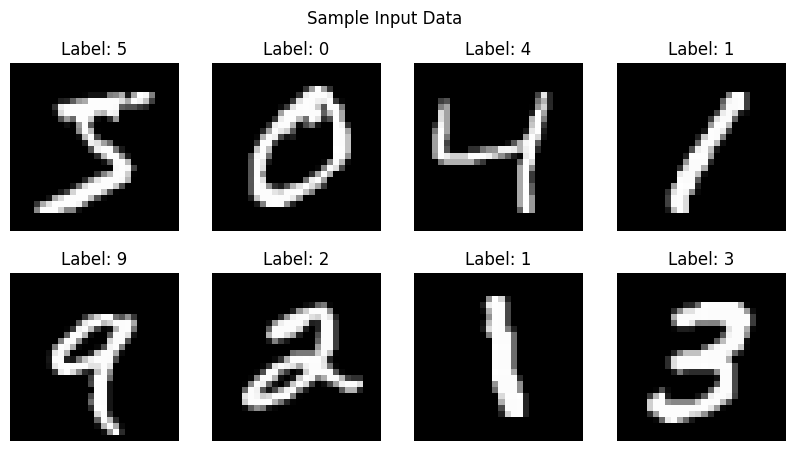

In [ ]:
# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Display a few samples of the input data
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
fig.suptitle('Sample Input Data')
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i], cmap='gray')
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis('off')
plt.show()

In [ ]:
# Reshape the data to include a single channel (grayscale)
x_train = x_train.reshape((x_train.shape[0], 28, 28, 1))
x_test = x_test.reshape((x_test.shape[0], 28, 28, 1))

# Normalize the pixel values to be between 0 and 1
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

# One-hot encode the labels
y_train = to_categorical(y_train, 10)
y_test  = to_categorical(y_test, 10)

# Data augmentation
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)
datagen.fit(x_train)

In [ ]:
# Build the CNN model
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Train the model using data augmentation
history = model.fit(datagen.flow(x_train, y_train, batch_size=128),
                    epochs=10,
                    validation_data=(x_test, y_test))

Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


469/469 ━━━━━━━━━━━━━━━━━━━━ 33s 56ms/step - accuracy: 0.6249 - loss: 1.1011 - val_accuracy: 0.9779 - val_loss: 0.0683
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 23s 48ms/step - accuracy: 0.9133 - loss: 0.2863 - val_accuracy: 0.9850 - val_loss: 0.0441
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 42s 49ms/step - accuracy: 0.9354 - loss: 0.2126 - val_accuracy: 0.9887 - val_loss: 0.0344
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 40s 47ms/step - accuracy: 0.9465 - loss: 0.1740 - val_accuracy: 0.9889 - val_loss: 0.0324
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step - accuracy: 0.9533 - loss: 0.1537 - val_accuracy: 0.9914 - val_loss: 0.0255
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 47ms/step - accuracy: 0.9586 - loss: 0.1366 - val_accuracy: 0.9911 - val_loss: 0.0246
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 42s 49ms/step - accuracy: 0.9617 - loss: 0.1256 - val_accuracy: 0.9919 - val_loss: 0.0229
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 23s 49ms/step - accuracy: 0.9639 - loss: 0.1183 - val_accurac

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9926 - loss: 0.0227
Test accuracy: 0.99
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Accuracy: 0.99
Sensitivity (Recall): 0.99
Precision: 0.99


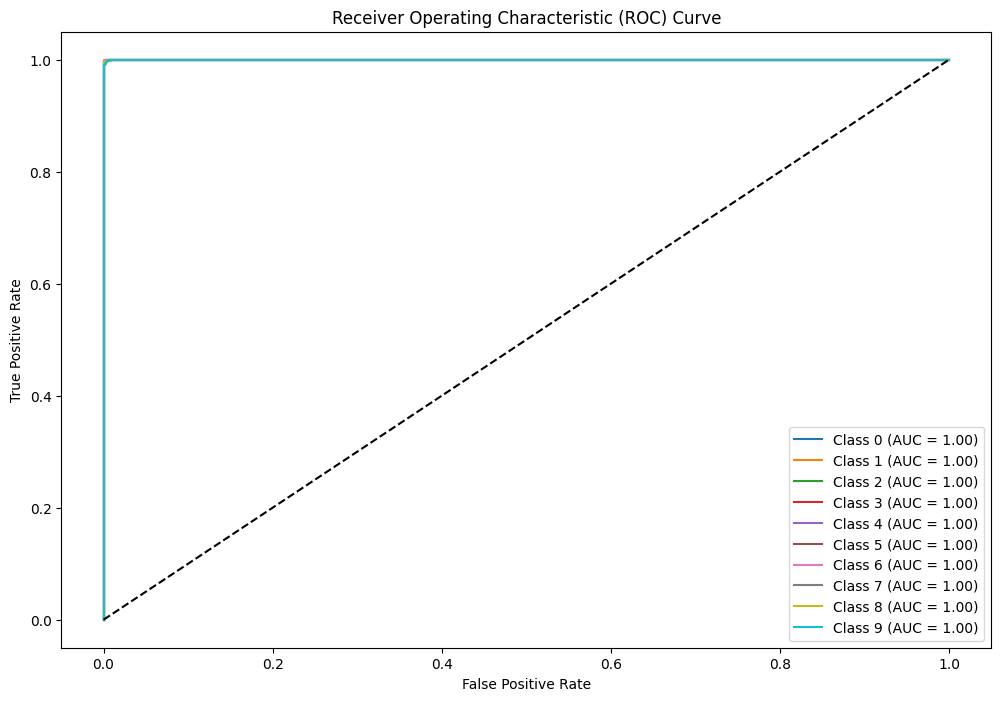

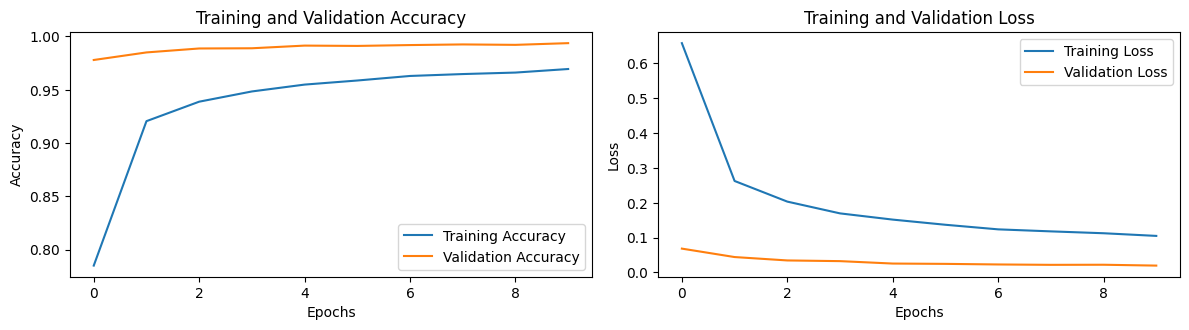

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


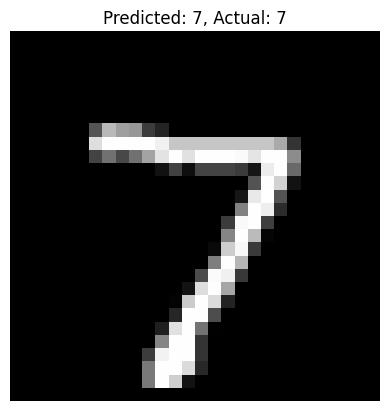

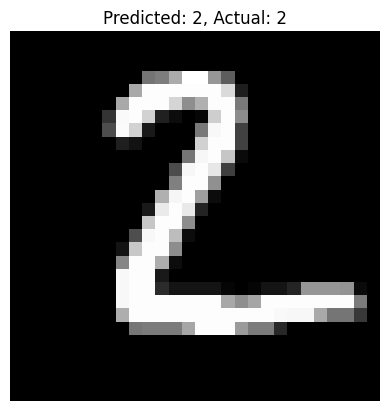

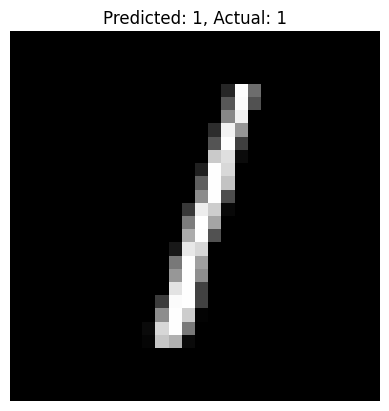

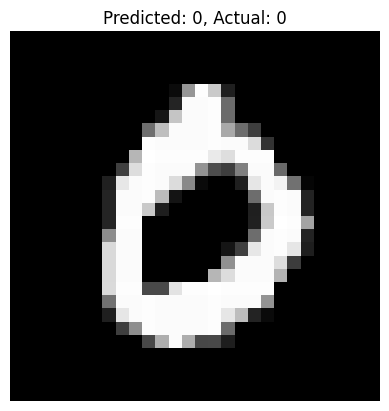

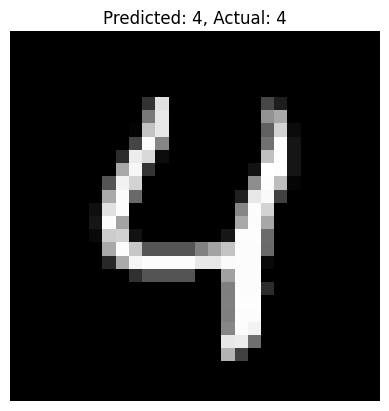

In [ ]:
# Evaluate the model
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_accuracy:.2f}")

# Calculate additional metrics
y_pred = model.predict(x_test)
y_test_classes = np.argmax(y_test, axis=1)
y_pred_classes = np.argmax(y_pred, axis=1)

accuracy = accuracy_score(y_test_classes, y_pred_classes)
recall = recall_score(y_test_classes, y_pred_classes, average='macro')
precision = precision_score(y_test_classes, y_pred_classes, average='macro')
conf_matrix = confusion_matrix(y_test_classes, y_pred_classes)

print(f"Accuracy: {accuracy:.2f}")
print(f"Sensitivity (Recall): {recall:.2f}")
print(f"Precision: {precision:.2f}")
# Plot ROC curve for each class
plt.figure(figsize=(12, 8))
for i in range(10):
    fpr, tpr, _ = roc_curve(y_test[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

# Plot training history
plt.figure(figsize=(12, 6))

# Plot training and validation accuracy
plt.subplot(2, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

# Plot training and validation loss
plt.subplot(2, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')

plt.tight_layout()
plt.show()

# Predict and visualize a few predictions
predictions = model.predict(x_test)

# Display some predictions
def plot_predictions(x_test, y_test, predictions, num_samples=5):
    for i in range(num_samples):
        plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
        plt.title(f"Predicted: {np.argmax(predictions[i])}, Actual: {np.argmax(y_test[i])}")
        plt.axis('off')
        plt.show()

plot_predictions(x_test, y_test, predictions, num_samples=5)